# Surface Mesh Segmentation Test

This notebook tests the surface mesh segmentation functionality.

## Imports and boiler-plate code

In [1]:
import unittest
import numpy as np
import sys
import os

# Add code directory to path to import pySHP modules
# Notebook is in: code/pySHP/tests/
# We need to add: code/ to the path
code_dir = r'C:\Users\Khaled Khairy\Dropbox\Projects\hot\Project_spherical_parameterization\code'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

from pySHP.surface_mesh import surface_mesh
from pySHP.shp_surface import shp_surface
from pySHP.utils import readoff
from pySHP.level1.mesh_segmentation_rw import mesh_segmentation_rw
from pySHP.level1.patch_info_gen import patch_info_gen

# PyVista: embedded interactive 3D in the notebook (trame backend)
# If you see "Loading..." and no plot: pip install 'pyvista[all,trame]' ipywidgets ; or run notebook in Jupyter Lab in browser.
import pyvista as pv
pv.set_jupyter_backend('trame')
print("PyVista: embedded interactive plots (trame)")

PyVista: embedded interactive plots (trame)


## Load Mesh Data

In [16]:
# Read OFF file
topic = 'test_set' #'scientific' #'misc_shapes'
file_name = 'echinocyte.off' #'planula_01.off' #'mushroom.off' #'test_mud_01.off' #'MaxPlankHead.off'
fn_shape = os.path.join('C:\\Users\\Khaled Khairy\\Dropbox\\Projects\\hot\\Project_spherical_parameterization\\code', 
'Matlab','shp_toolbox-main', 'shp_toolbox-main', 'test_data', 'off', 
topic,
file_name 
)
X, F = readoff(fn_shape)
m = surface_mesh(X, F)
# optionally subdivide mesh using densify
#m.simplify_mesh(1000)
m.plot()
m.disp()
# now remesh



Widget(value='<iframe src="http://localhost:52994/index.html?ui=P_0x2347290e660_21&reconnect=auto" class="pyvi…

Mesh Information
Vertices:            1002
Faces:               2000
Edges:               3000
--------------------------------------------------
Euler characteristic: 2  (V - E + F)
Genus:               0  (0=sphere, 1=torus, ...)
--------------------------------------------------
Is closed:           True
Is manifold:         True
Boundary edges:      0
Boundary loops:      0
Connected components: 1
Area:                152.011
Volume:              105.884


{'n_vertices': 1002,
 'n_faces': 2000,
 'n_edges': 3000,
 'euler_characteristic': 2,
 'genus': 0,
 'is_closed': True,
 'is_manifold': True,
 'n_boundary_edges': 0,
 'n_boundary_loops': 0,
 'n_components': 1}

## Mesh Preprocessing and Quality Check

In [17]:
## Mesh Preprocessing and Quality Check
m.repair_mesh()
components = m.find_disconnected_surfaces()
m.keep_largest_surface()
m.info()  # Check initial topology
m.check_mesh_integrity()  # Check for problems
m.print_mesh_quality()  # See triangle quality

#m.remesh_uniform(1000, n_iterations=10, smooth_iterations=5)
m.simplify_mesh(2000)
#m.remesh_curvature_adaptive(500, curvature_strength=1.0, n_iterations=5, smooth_iterations=5)
m.plot()
m.disp()

Starting mesh repair sequence...
Initial mesh: 1002 vertices, 2000 faces
Removing duplicate vertices and faces...
  No duplicate vertices or faces found
Mesh repair complete: 1002 vertices, 2000 faces
Removing isolated vertices...
  No isolated vertices found
Mesh repair complete: 1002 vertices, 2000 faces
Performing deep mesh cleaning...
Mesh repair complete: 1002 vertices, 2000 faces

Mesh connectivity: Single connected component (2000 faces)

------------------------------------------------------------
Checking and fixing normal/winding consistency...
------------------------------------------------------------
Fixing normal/winding consistency...
  Fixed 28 flipped faces (normals now point consistently outward)
Mesh repair complete: 1002 vertices, 2000 faces

Mesh repair complete!
Final mesh: 1002 vertices, 2000 faces
Mesh appears to be a closed shape (Euler characteristic = 2)
Found 1 disconnected surface components
  Component 0: 2000 faces
Mesh is already a single connected comp

Widget(value='<iframe src="http://localhost:52994/index.html?ui=P_0x2340eaa96d0_22&reconnect=auto" class="pyvi…

Mesh Information
Vertices:            1002
Faces:               2000
Edges:               3000
--------------------------------------------------
Euler characteristic: 2  (V - E + F)
Genus:               0  (0=sphere, 1=torus, ...)
--------------------------------------------------
Is closed:           True
Is manifold:         True
Boundary edges:      0
Boundary loops:      0
Connected components: 1
Area:                152.011
Volume:              105.884


{'n_vertices': 1002,
 'n_faces': 2000,
 'n_edges': 3000,
 'euler_characteristic': 2,
 'genus': 0,
 'is_closed': True,
 'is_manifold': True,
 'n_boundary_edges': 0,
 'n_boundary_loops': 0,
 'n_components': 1}

## Fine Mesh Segmentation

Generate mesh segmentation using random walk method.

In [18]:
# Generate mesh segmentation
nseeds = 12  # Use 6 seeds for testing
sigma = 1.0
curvature_weight = -1e-6  # 0.0 = no curvature, 1.0 = full curvature weighting
print("\n" + "="*60)
print(f"Calling mesh_segmentation_rw with verbose=True, plot_intermediate=True")
print(f"  sigma={sigma}, curvature_weight={curvature_weight}")
print("="*60)
ms, L, slix, P, Pconn = mesh_segmentation_rw(m, nseeds, sigma, curvature_weight=curvature_weight, verbose=True, plot_intermediate=True)



Calling mesh_segmentation_rw with verbose=True, plot_intermediate=True
  sigma=1.0, curvature_weight=-1e-06
mesh_segmentation_rw: Starting segmentation
Input mesh: 1002 vertices, 2000 faces
Face neighbors matrix: (2000, 2000), 6000 non-zero entries
Face neighbor counts: min=3, max=3, mean=3.00
Face neighbor symmetry check (sample of 100): 100.0% symmetric
Using 12 seed faces: [ 350  722  952  200 1110  733 1734  927 1406  318]...
Curvature weighting disabled (curvature_weight=0), using uniform transition probabilities
Modifying 6000 matrix entries (neighbor pairs) with uniform weights (curvature_weight=0)
  Verified: Matrix modification working correctly
Diagonal before addition: min=0.0000, max=0.0000, non-zero count=0
Matrix A: (2000, 2000), 8000 non-zero entries
Matrix A value range: [-0.0000, 1.0000]
Diagonal after addition: min=1.0000, max=1.0000, should all be >= 1.0, actual min=1.0000
Matrix A: 2000 diagonal entries, 6000 off-diagonal entries
Row sums: min=1.0000, max=1.0000, m

Widget(value='<iframe src="http://localhost:52994/index.html?ui=P_0x23430185bb0_23&reconnect=auto" class="pyvi…

Plotted initial segmentation with seed faces highlighted (interactive PyVista plot)

------------------------------------------------------------
Step 1: Smoothing borders (median of neighbors)
------------------------------------------------------------
After smoothing: 12 unique labels


Widget(value='<iframe src="http://localhost:52994/index.html?ui=P_0x2342198fe00_24&reconnect=auto" class="pyvi…

Plotted after first smoothing

------------------------------------------------------------
Step 2: Fixing trapped faces
------------------------------------------------------------
After fixing trapped: 12 unique labels

------------------------------------------------------------
Step 3: Sequential smoothing (in-place updates)
------------------------------------------------------------
Final segmentation: 12 unique labels
Label distribution: {np.int64(1): np.int64(170), np.int64(2): np.int64(166), np.int64(3): np.int64(153), np.int64(4): np.int64(182), np.int64(5): np.int64(211), np.int64(6): np.int64(167), np.int64(7): np.int64(173), np.int64(8): np.int64(162), np.int64(9): np.int64(170), np.int64(10): np.int64(176), np.int64(11): np.int64(146), np.int64(12): np.int64(124)}
Output mesh: 1002 vertices, 2000 faces (SAME as input)


Widget(value='<iframe src="http://localhost:52994/index.html?ui=P_0x2340cf3c6e0_25&reconnect=auto" class="pyvi…

Plotted final segmentation

------------------------------------------------------------
Building patch structures P and Pconn
------------------------------------------------------------
Number of patches: 12
Patch connectivity matrix: (12, 12)
Number of patch connections: 36
mesh_segmentation_rw: COMPLETE
NOTE: Output mesh 'm' is the SAME mesh as input, with face_labels added.
      The simplified mesh is created later in patch_info_gen as PM.pm


### Verify Segmentation Results

In [19]:
# Report the results of the mesh segmentation
ms.plot_segmentation_with_seeds(slix)
print("\n" + "="*60)
print("Verification: ms should be the SAME mesh as m, with face_labels added")
print("="*60)
print(f"m has {len(m.X)} vertices, {len(m.F)} faces")
print(f"ms has {len(ms.X)} vertices, {len(ms.F)} faces")
print(f"Are they the same object? {m is ms}")
print(f"Does ms have face_labels? {hasattr(ms, 'face_labels') and ms.face_labels is not None}")
if hasattr(ms, 'face_labels') and ms.face_labels is not None:
    print(f"Number of unique labels: {len(np.unique(ms.face_labels))}")
    print(f"Label range: [{ms.face_labels.min()}, {ms.face_labels.max()}]")

Plotted 12 seed faces as red spheres (radius = 0.2206, avg edge length = 0.4412)


Widget(value='<iframe src="http://localhost:52994/index.html?ui=P_0x2343c54d6a0_26&reconnect=auto" class="pyvi…


Verification: ms should be the SAME mesh as m, with face_labels added
m has 1002 vertices, 2000 faces
ms has 1002 vertices, 2000 faces
Are they the same object? True
Does ms have face_labels? True
Number of unique labels: 12
Label range: [1, 12]


## Generate Patches and Simplified Mesh (made of key vertices and center vertices)

In [20]:
# Generate patches and patch mesh
m_seg, PM, Pconn = patch_info_gen(ms, P, Pconn)

# Report the results of the patch generation
print("\n" + "="*60)
print(f"\nSegmentation complete:")
print(f"  Number of patches: {len(np.unique(L))}")
print(f"  Mesh has {len(m_seg.F)} faces")
if 'pm' in PM:
    print(f"  Simplified mesh has {len(PM['pm'].F)} faces")


KEY VERTEX DETECTION DEBUG:
  Number of patches: 12
  Patch 0: 30 edge faces
  Patch 0: pev has 306 entries
  Patch 0: 49 unique edge vertices
    Vertex 8: touches 2 patches: [0 7]
    Vertex 25: touches 1 patches: [0]
    Vertex 27: touches 3 patches: [0 4 9]
  Patch 0: Found 4 key vertices
  Patch 1: Found 5 key vertices
  Patch 2: Found 4 key vertices
  Patch 3: Found 4 key vertices
  Patch 4: Found 8 key vertices
  Patch 5: Found 5 key vertices
  Patch 6: Found 4 key vertices
  Patch 7: Found 5 key vertices
  Patch 8: Found 4 key vertices
  Patch 9: Found 5 key vertices
  Patch 10: Found 6 key vertices
  Patch 11: Found 6 key vertices


KEY ACCUMULATION RESULT:
  Total keys found: 60
  Unique key vertices: 20
  Key vertices: [ 16  27  50  74 208 214 217 229 244 321]...


generate_simplified_mesh DEBUG:
  Unique keys (indx): 20
  Sentinel vertices added: 0
  Total key vertices in mesh (nkeys): 20
  npatches: 12
  Keys shape: (60, 3)
  Keys (first 5): [[  0  27   9]
 [  0  74 130]


### Visualize Simplified Mesh

In [21]:
# [1] Plot the simplified mesh
print("\n[1] Plotting simplified mesh...")
surface_mesh.plot_simplified_mesh(PM, show_keys=True, show_cv=True)


[1] Plotting simplified mesh...


Widget(value='<iframe src="http://localhost:52994/index.html?ui=P_0x2343c53b9e0_27&reconnect=auto" class="pyvi…

### Verify Patch Edges in PM


In [22]:
# [4] Show border vertices on the full mesh
print("\n[4] Plotting full mesh with border vertices...")
m_seg.plot_border()


[4] Plotting full mesh with border vertices...


Widget(value='<iframe src="http://localhost:52994/index.html?ui=P_0x2343c53a300_28&reconnect=auto" class="pyvi…

## Spherical Parameterization of Simplified Mesh


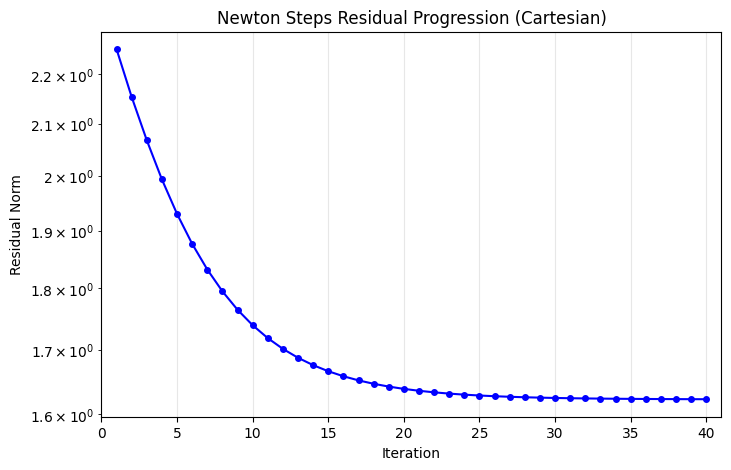

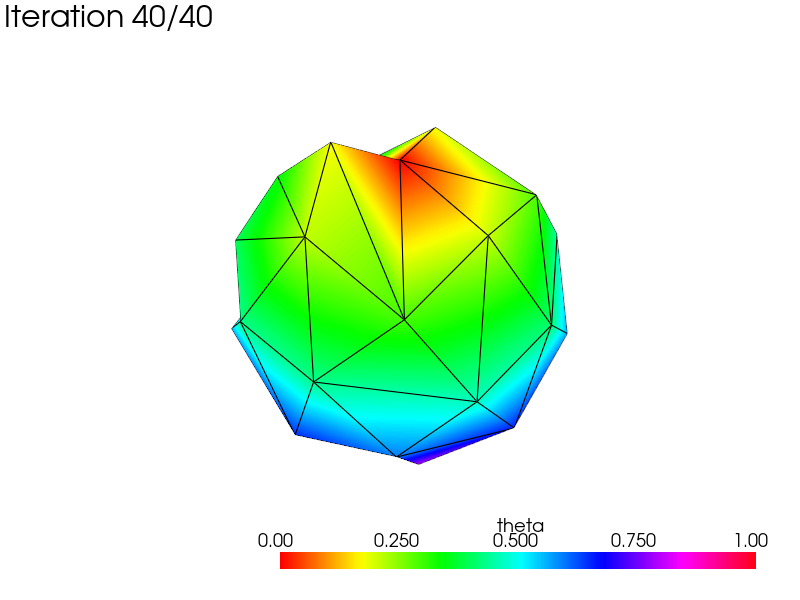

Iteration 40/40: Residual norm = 1.622715e+00


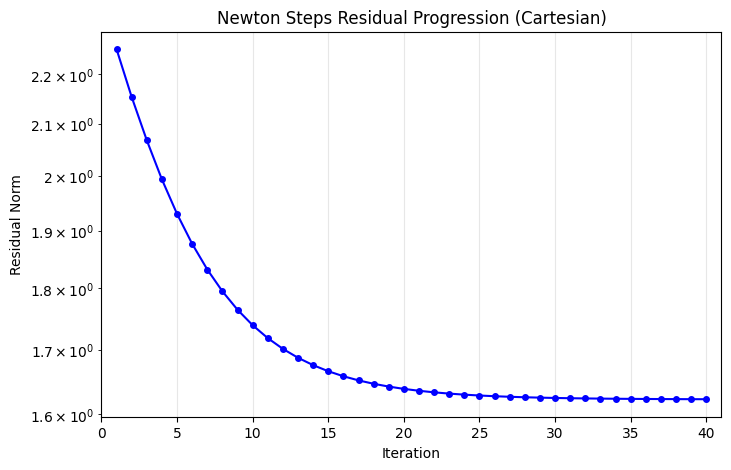

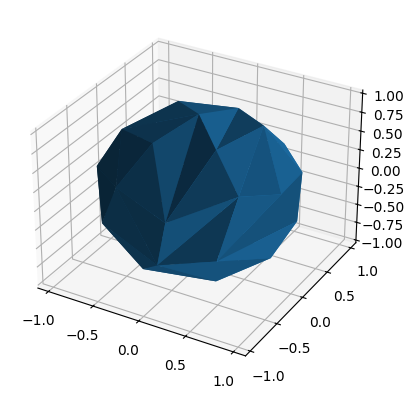

Widget(value='<iframe src="http://localhost:52994/index.html?ui=P_0x2340cf81580_31&reconnect=auto" class="pyvi…

In [23]:
# Spherically parameterize simplified mesh (optimization_method 3: area + edge-length)
from pySHP.level1.set_edge_n_fine_vertices import set_edge_n_fine_vertices_from_PM

pm = PM['pm']
ms = surface_mesh(pm.X, pm.F)

# Set per-edge fine-vertex counts from PM (same border chains as patch parameterization)
ms = set_edge_n_fine_vertices_from_PM(ms, PM)
# start out with area minimization
ms.needs_mesh2sphere = 1
ms.optimization_method = 1   # area Newton steps
ms.newton_niter = 40
ms.newton_step = 0.1         # area steps
ms.newton_step_edge = 0.05   # edge-length steps
ms.bijective_plot_flag = 2
ms.map2sphere()
ms.plot_spherical_parameterization()

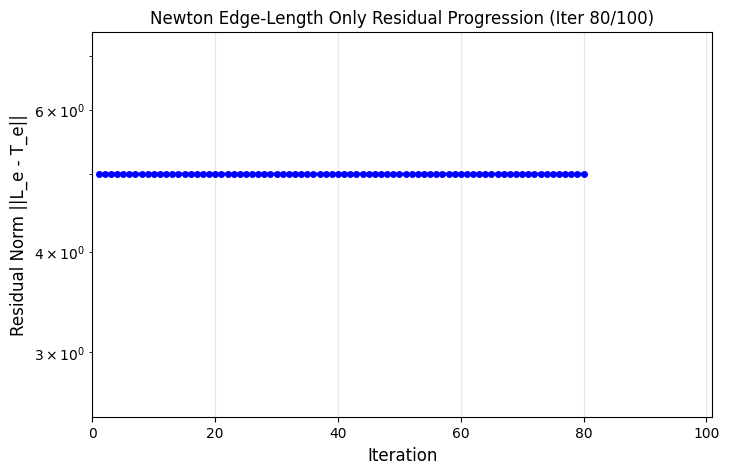

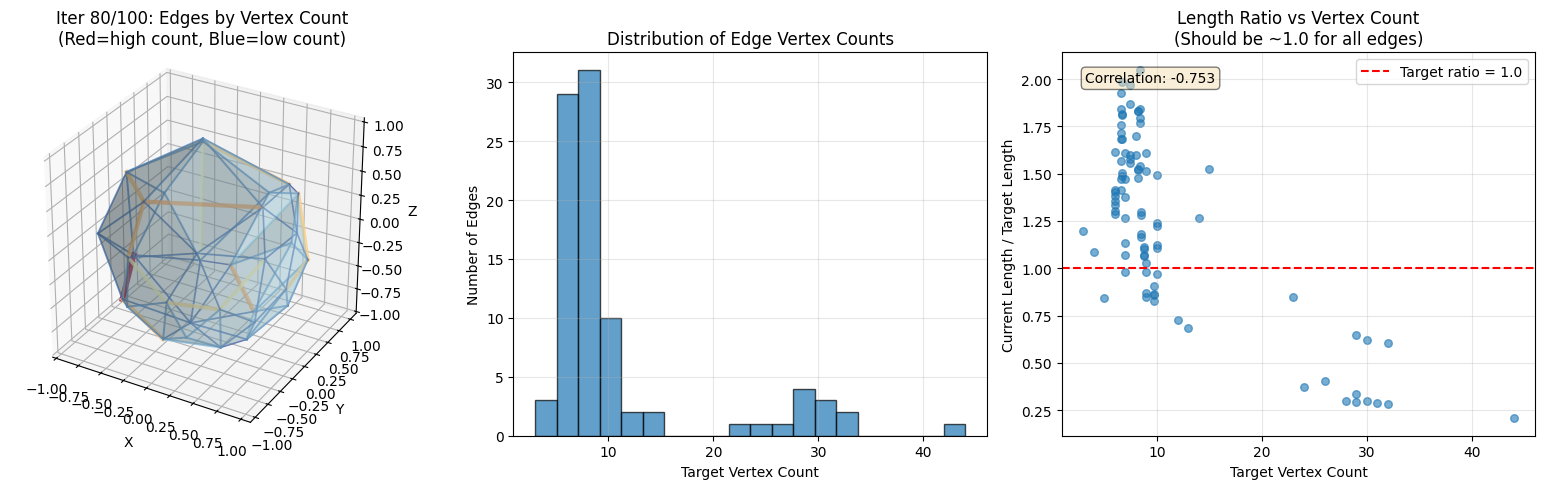

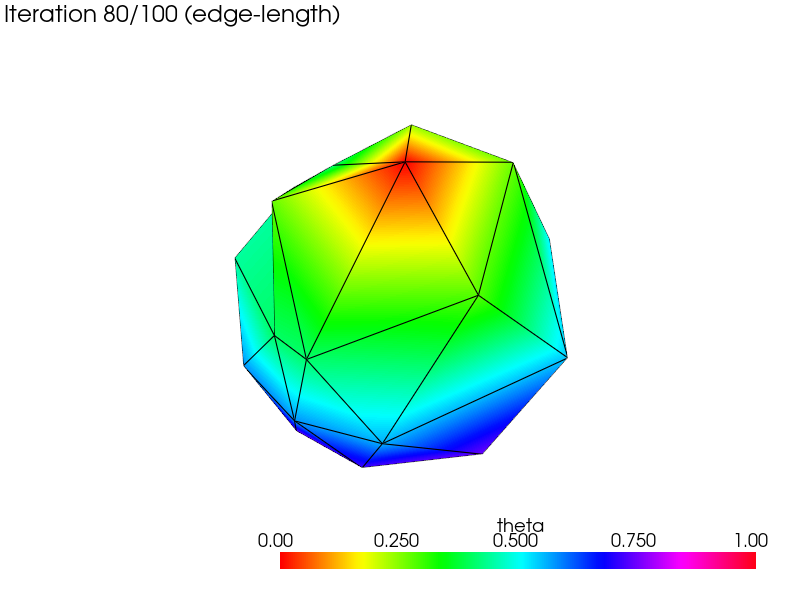

Iteration 80/100: Residual norm = 4.993751e+00 (edge-length)
  Reduction factor: 1.00x from initial
  Length/vertex_count correlation: -0.753 (target: ~1.0, higher is better)
  Mean length ratio (L/T): 1.248 (target: 1.0)
Iteration 81/100: Minimizing edge_length
  Iter 80: ||EdgeResiduals||=4.993751e+00
Iteration 82/100: Minimizing edge_length
  Iter 81: ||EdgeResiduals||=4.993751e+00
Iteration 83/100: Minimizing edge_length
  Iter 82: ||EdgeResiduals||=4.993751e+00
Iteration 84/100: Minimizing edge_length
  Iter 83: ||EdgeResiduals||=4.993751e+00
Iteration 85/100: Minimizing edge_length
  Iter 84: ||EdgeResiduals||=4.993751e+00


In [ ]:

# now minimize  edge length
# Optional: use relative error so all edges weighted equally (can help correlation)
ms.edge_length_relative_error = True   # try True if correlation stays negative
ms.optimization_method = 4
ms.newton_niter = 100
ms.newton_step_edge = 0.5
ms.map2sphere()
ms.plot_spherical_parameterization()



### Update PM with optized simplified mesh values

In [ ]:
# Update PM['pm'] with the theta and phi values from the parameterized simplified mesh
# After successful spherical parameterization of ms, copy t and p to PM['pm']
print("="*60)
print("Updating PM['pm'] with parameterized theta and phi values")
print("="*60)

# Copy the parameterized values from ms to PM['pm']
PM['pm'].t = ms.t.copy()
PM['pm'].p = ms.p.copy()

print(f"Updated PM['pm'] with theta and phi values")
print(f"  PM['pm'] has {len(PM['pm'].X)} vertices")
print(f"  Theta range: [{PM['pm'].t.min():.4f}, {PM['pm'].t.max():.4f}]")
print(f"  Phi range: [{PM['pm'].p.min():.4f}, {PM['pm'].p.max():.4f}]")
print("\n" + "="*60)

## Patch-based fine-mesh spherical parameterization

In [ ]:
# Parameterize the fine mesh patches using the simplified mesh parameterization
from pySHP.level1.parameterize_patches_cart import parameterize_patches_cart

print("="*60)
print("Parameterizing fine mesh patches")
print("="*60)
print(f"Number of patches to parameterize: {PM['npatches']}")

# Parameterize all patches
# This will project each fine mesh patch onto the sphere using the boundary
# conditions from the simplified mesh parameterization
PM = parameterize_patches_cart(PM, plot_flag=1)

print("Patch parameterization complete!")
print(f"Parameterized {PM['npatches']} patches")


In [ ]:
# Debug visualization for a specific patch
# This shows: fine mesh, border vertices, chain vertices, sentinel vertices
print("="*60)
print("Patch Debug Visualization")
print("="*60)

# Select patch to visualize (change this to debug different patches)
patch_idx = 5  # Change this to visualize different patches (0-indexed)

if patch_idx >= PM['npatches']:
    print(f"Error: Patch index {patch_idx} is out of range (max: {PM['npatches']-1})")
else:
    print(f"Visualizing patch {patch_idx}")
    
    try:
        import pyvista as pv
        
        # Get the patch mesh
        patm = PM['P'][patch_idx][0]
        
        # Get border vertices
        border_vertices = np.where(patm.border_vertex)[0] if hasattr(patm, 'border_vertex') and patm.border_vertex is not None else np.array([])
        
        # Get chain vertices from edge_dat
        chain_vertices = set()
        if 'patch' in PM and patch_idx in PM.get('patch', {}):
            # Use refined edge chains
            for edge_chain in PM['patch'][patch_idx]['edge_dat']:
                chain_vertices.update(edge_chain.astype(int))
        else:
            # Use PM.edge_dat
            for eix in range(len(PM['Edges'])):
                if PM['Edges'][eix, 0] == patch_idx or PM['Edges'][eix, 1] == patch_idx:
                    if eix < len(PM['edge_dat']) and len(PM['edge_dat'][eix]) > 0:
                        chain_vertices.update(PM['edge_dat'][eix].astype(int))
        chain_vertices = np.array(list(chain_vertices))
        
        # Get sentinel vertices for this patch
        sentinel_vertices = set()
        for eix in range(len(PM['Edges'])):
            if PM['Edges'][eix, 0] == patch_idx or PM['Edges'][eix, 1] == patch_idx:
                if eix < len(PM['sentinels']):
                    s1 = int(PM['sentinels'][eix, 0])
                    s2 = int(PM['sentinels'][eix, 1])
                    if s1 >= 0 and s1 < len(m.X):
                        sentinel_vertices.add(s1)
                    if s2 >= 0 and s2 < len(m.X):
                        sentinel_vertices.add(s2)
        sentinel_vertices = np.array(list(sentinel_vertices))
        
        # Create subplot layout: 2x3 grid (5 plots: 2x2 + 1 extra)
        plotter = pv.Plotter(shape=(2, 3))
        
        # ========== Plot 1: Fine mesh of the patch ==========
        plotter.subplot(0, 0)
        # Create mesh from patch
        num_faces = patm.F.shape[0]
        faces_with_n_vertices = np.hstack((np.full((num_faces, 1), 3), patm.F))
        cells = faces_with_n_vertices.flatten()
        mesh_pv = pv.PolyData(patm.X, cells)
        plotter.add_mesh(mesh_pv, color='lightblue', show_edges=True, edge_color='black', line_width=0.5)
        plotter.add_text(f'Patch {patch_idx}: Fine Mesh\n({len(patm.X)} vertices, {len(patm.F)} faces)', font_size=10)
        plotter.background_color = 'white'
        
        # ========== Plot 2: Patch mesh with border vertices marked ==========
        plotter.subplot(0, 1)
        plotter.add_mesh(mesh_pv, color='lightblue', show_edges=True, edge_color='black', line_width=0.5)
        if len(border_vertices) > 0:
            border_points = pv.PolyData(patm.X[border_vertices])
            plotter.add_mesh(border_points, color='yellow', point_size=15,
                           render_points_as_spheres=True, label=f'Border ({len(border_vertices)})')
        plotter.add_text(f'Patch {patch_idx}: Border Vertices\n(Yellow spheres)', font_size=10)
        plotter.background_color = 'white'
        plotter.add_legend()
        
        # ========== Plot 3: Patch mesh with chain vertices marked ==========
        plotter.subplot(1, 0)
        plotter.add_mesh(mesh_pv, color='lightblue', show_edges=True, edge_color='black', line_width=0.5)
        if len(chain_vertices) > 0:
            # Filter chain vertices that are in the patch
            chain_in_patch = chain_vertices[chain_vertices < len(patm.X)]
            if len(chain_in_patch) > 0:
                chain_points = pv.PolyData(patm.X[chain_in_patch])
                plotter.add_mesh(chain_points, color='orange', point_size=12,
                               render_points_as_spheres=True, label=f'Chain ({len(chain_in_patch)})')
        plotter.add_text(f'Patch {patch_idx}: Chain Vertices\n(Orange spheres)', font_size=10)
        plotter.background_color = 'white'
        plotter.add_legend()
        
        # ========== Plot 4: Full object mesh with patch border and sentinels ==========
        plotter.subplot(1, 1)
        # Create full mesh
        num_faces_full = m.F.shape[0]
        faces_with_n_vertices_full = np.hstack((np.full((num_faces_full, 1), 3), m.F))
        cells_full = faces_with_n_vertices_full.flatten()
        mesh_full = pv.PolyData(m.X, cells_full)
        
        # Color only the patch faces
        face_colors = np.ones((len(m.F), 3)) * 0.9  # Light gray for all faces
        if hasattr(m, 'face_labels') and m.face_labels is not None:
            # Get faces belonging to this patch
            unique_labels = np.unique(m.face_labels)
            if patch_idx < len(unique_labels):
                patch_label = unique_labels[patch_idx]
                patch_faces = np.where(m.face_labels == patch_label)[0]
                face_colors[patch_faces] = [0.5, 0.8, 1.0]  # Light blue for patch faces
        
        mesh_full['face_colors'] = face_colors
        plotter.add_mesh(mesh_full, scalars='face_colors', rgb=True, show_edges=True, 
                        edge_color='black', line_width=0.3, opacity=0.7)
        
        # Mark border vertices of this patch on the full mesh
        if len(border_vertices) > 0:
            # Map border vertices from patch to full mesh (they use same indices)
            border_points_full = pv.PolyData(m.X[border_vertices])
            plotter.add_mesh(border_points_full, color='yellow', point_size=12,
                           render_points_as_spheres=True, label=f'Border ({len(border_vertices)})')
        
        # Mark sentinel vertices as red spheres
        if len(sentinel_vertices) > 0:
            sentinel_points = pv.PolyData(m.X[sentinel_vertices])
            plotter.add_mesh(sentinel_points, color='red', point_size=20,
                           render_points_as_spheres=True, label=f'Sentinels ({len(sentinel_vertices)})')
        
        plotter.add_text(f'Full Mesh: Patch {patch_idx} Highlighted\n(Yellow=border, Red=sentinels)', font_size=10)
        plotter.background_color = 'white'
        plotter.add_legend()
        
        # ========== Plot 5: Spherical parameterization of the patch ==========
        plotter.subplot(1, 2)
        
        # Check if patch has t and p values
        if patm.t is not None and patm.p is not None and np.any(patm.t != 0) and np.any(patm.p != 0):
            # Convert spherical coordinates to Cartesian on unit sphere
            # Use the same import as the rest of the codebase
            from pySHP.utils import kk_sph2cart
            u, v, w = kk_sph2cart(patm.t, patm.p, np.ones(len(patm.p)))
            X_sph = np.column_stack([u, v, w])
            
            # Create mesh on sphere
            num_faces_sph = patm.F.shape[0]
            faces_with_n_vertices_sph = np.hstack((np.full((num_faces_sph, 1), 3), patm.F))
            cells_sph = faces_with_n_vertices_sph.flatten()
            mesh_sph = pv.PolyData(X_sph, cells_sph)
            
            # Add reference sphere (semi-transparent)
            sphere = pv.Sphere(radius=0.98, theta_resolution=30, phi_resolution=30)
            plotter.add_mesh(sphere, color='cyan', opacity=0.3, show_edges=False)
            
            # Plot the parameterized patch on sphere
            plotter.add_mesh(mesh_sph, color='lightblue', show_edges=True, 
                           edge_color='black', line_width=0.5, opacity=0.9)
            
            # Mark border vertices on sphere
            if len(border_vertices) > 0:
                border_vertices_valid = border_vertices[(patm.t[border_vertices] != 0) & (patm.p[border_vertices] != 0)]
                if len(border_vertices_valid) > 0:
                    border_points_sph = pv.PolyData(X_sph[border_vertices_valid])
                    plotter.add_mesh(border_points_sph, color='yellow', point_size=12,
                                   render_points_as_spheres=True, label=f'Border ({len(border_vertices_valid)})')
            
            plotter.add_text(f'Patch {patch_idx}: Spherical Parameterization\n(On unit sphere)', font_size=10)
            plotter.background_color = 'black'
            plotter.add_legend()
        else:
            plotter.add_text(f'Patch {patch_idx}: No Parameterization\n(t and p values not available)', font_size=10)
            plotter.background_color = 'white'
        
        # Show the plot
        plotter.show()
        
        # Print diagnostic information
        print(f"\nPatch {patch_idx} Diagnostics:")
        print(f"  Patch vertices: {len(patm.X)}")
        print(f"  Patch faces: {len(patm.F)}")
        print(f"  Border vertices: {len(border_vertices)}")
        print(f"  Chain vertices: {len(chain_vertices)}")
        print(f"  Sentinel vertices: {len(sentinel_vertices)}")
        if len(sentinel_vertices) > 0:
            print(f"    Sentinel indices: {sentinel_vertices}")
        
        # Check overlap
        border_set = set(border_vertices)
        chain_set = set(chain_vertices[chain_vertices < len(patm.X)])
        overlap = border_set.intersection(chain_set)
        border_only = border_set - chain_set
        chain_only = chain_set - border_set
        
        print(f"\n  Border-Chain Overlap:")
        print(f"    Overlap: {len(overlap)} vertices")
        print(f"    Border-only: {len(border_only)} vertices")
        print(f"    Chain-only: {len(chain_only)} vertices")
        
        # Spherical parameterization diagnostics
        if patm.t is not None and patm.p is not None:
            valid_tp = (patm.t != 0) & (patm.p != 0)
            num_valid = np.sum(valid_tp)
            print(f"\n  Spherical Parameterization:")
            print(f"    Vertices with valid t,p: {num_valid} / {len(patm.t)}")
            if num_valid > 0:
                print(f"    Theta range: [{patm.t[valid_tp].min():.4f}, {patm.t[valid_tp].max():.4f}]")
                print(f"    Phi range: [{patm.p[valid_tp].min():.4f}, {patm.p[valid_tp].max():.4f}]")
        else:
            print(f"\n  Spherical Parameterization: Not available (t or p is None)")
        
    except ImportError:
        print("PyVista not available for visualization")
    except Exception as e:
        print(f"Error creating visualization: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)


In [ ]:
# Assemble full parameterized mesh from all patches
# This combines the t and p values from all parameterized patches into the full mesh
print("="*60)
print("Assembling full parameterized mesh from all patches")
print("="*60)

# Use m_seg (the segmented mesh) as the base for the full parameterized mesh
# m_seg has the same vertices and faces as the original mesh, with face_labels
mp = surface_mesh(m_seg.X.copy(), m_seg.F.copy())
mp.face_labels = m_seg.face_labels.copy() if hasattr(m_seg, 'face_labels') and m_seg.face_labels is not None else None

# Initialize t and p arrays
mp.t = np.zeros(len(mp.X))
mp.p = np.zeros(len(mp.X))

# Copy t and p values from each parameterized patch to the full mesh
for pix in range(PM['npatches']):
    pat = PM['P'][pix][0]  # Get the parameterized patch
    # Get all vertex indices used in this patch
    Vix = np.unique(pat.F.flatten())
    
    # Copy t and p values from patch to full mesh
    for v in Vix:
        if v < len(mp.t) and v < len(pat.t) and pat.t[v] != 0:
            mp.t[v] = pat.t[v]
        if v < len(mp.p) and v < len(pat.p) and pat.p[v] != 0:
            mp.p[v] = pat.p[v]

print(f"Assembled full parameterized mesh:")
print(f"  Total vertices: {len(mp.X)}")
print(f"  Vertices with t values: {np.sum(mp.t != 0)}")
print(f"  Vertices with p values: {np.sum(mp.p != 0)}")
print(f"  Theta range: [{mp.t[mp.t != 0].min():.4f}, {mp.t[mp.t != 0].max():.4f}]")
print(f"  Phi range: [{mp.p[mp.p != 0].min():.4f}, {mp.p[mp.p != 0].max():.4f}]")
print("\n" + "="*60)

In [ ]:
# Plot the full parameterized mesh on the sphere
# This shows all patches together on the sphere, similar to the MATLAB plot_spherical_parameterization(mp)
print("="*60)
print("Plotting full parameterized mesh (all patches combined)")
print("="*60)

# Plot the full mesh spherical parameterization
mp.plot_spherical_parameterization(flag=0)  # flag=0: no reference sphere, flag=1: with reference sphere
print("Full parameterized mesh plotted on sphere")
print("\n" + "="*60)

## Final parameterization

In [ ]:
# Final Step: Spherical Harmonics Projection and Export
# Add this as a new cell in test_surface_mesh_segmentation.ipynb after cell 11

print("="*60)
print("Spherical Harmonics Projection and Export")
print("="*60)

# Step 1: Assemble full parameterized mesh from all patches
from pySHP.level1.assemble_parameterized_mesh import assemble_parameterized_mesh

print("\n[Step 1] Assembling full parameterized mesh from all patches...")
m_param = assemble_parameterized_mesh(m_seg, PM)
m_param.optimization_method = 2  # Use alternating area/shear correction
m_param.newton_niter = 100        # Number of iterations
m_param.newton_step = 0.2        # Step factor
m_param.map2sphere()
m_param.needs_map2sphere = 0


In [ ]:
L_max: int = 32
s = shp_surface(m_param, L_max)
#s.plot(nico=3)
print(f"  Spherical harmonics surface created:")
print(f"    L_max: {s.L_max}")
print(f"    Number of coefficients: {len(s.xc)}")
print(f"    Residual (reconstruction error): {np.linalg.norm(s.residual):.6e}")

# Step 3: Export to .shp3 file
print("\n[Step 3] Exporting to .shp3 file...")
output_filename = "parameterized_mesh.shp3"  # Change this to your desired filename
s.export_shp3(output_filename)

print("\n" + "="*60)
print("Spherical harmonics projection complete!")
print(f"  Output file: {output_filename}")
print("="*60)

# Optional: Visualize the spherical harmonics reconstruction
print("\n[Optional] Visualizing spherical harmonics reconstruction...")

import pyvista as pv

# Get mesh from spherical harmonics
m_shp, X_shp, F_shp, Y_LK, t_shp, p_shp = s.get_mesh(nico=3)

# Create plotter
plotter = pv.Plotter(shape=(1, 2))

# Plot 1: Original parameterized mesh on sphere
plotter.subplot(0, 0)
# Convert t, p to Cartesian on unit sphere
from pySHP.utils import kk_sph2cart
u, v, w = kk_sph2cart(m_param.t, m_param.p, np.ones(len(m_param.p)))
X_sph_orig = np.column_stack([u, v, w])

# Create mesh
num_faces_orig = m_param.F.shape[0]
faces_with_n_vertices_orig = np.hstack((np.full((num_faces_orig, 1), 3), m_param.F))
cells_orig = faces_with_n_vertices_orig.flatten()
mesh_orig = pv.PolyData(X_sph_orig, cells_orig)
plotter.add_mesh(mesh_orig, color='lightblue', show_edges=True, 
                edge_color='black', line_width=0.5, opacity=1.0)
plotter.add_text('Original Parameterized Mesh\n(on unit sphere)', font_size=10)
plotter.background_color = 'black'

# Plot 2: Spherical harmonics reconstruction
plotter.subplot(0, 1)
# Create mesh from SH coefficients
num_faces_shp = F_shp.shape[0]
faces_with_n_vertices_shp = np.hstack((np.full((num_faces_shp, 1), 3), F_shp))
cells_shp = faces_with_n_vertices_shp.flatten()
mesh_shp = pv.PolyData(X_shp, cells_shp)
plotter.add_mesh(mesh_shp, color='lightgreen', show_edges=True, 
                edge_color='black', line_width=0.5, opacity=1.0)
plotter.add_text('Spherical Harmonics Reconstruction\n(L_max={})'.format(L_max), font_size=10)
plotter.background_color = 'black'
plotter.show()

s.plot(nico = 5)
m_param.plot()
# quantify shear
shear_sph, summary_sph = m_param.compute_shear_spherical_mesh()
print("Shear (spherical):", summary_sph['mean'])
m_param.plot_shear_heatmap_spherical_mesh(title='Shear on sphere (fine)')
m_param.plot_shear_heatmap_3d_mesh(title='Shear on 3D (fine)')

## Correct for shear

In [ ]:
m_param.optimization_method = 5  # Use shear correction
m_param.newton_niter = 200        # Number of iterations
m_param.newton_step = 0.02        # Step factor
m_param.prevent_flip = True
m_param.map2sphere()
m_param.needs_map2sphere = 0

# now repeat spherical harmonics projection
L_max: int = 32
s = shp_surface(m_param, L_max)
#s.plot(nico=3)
print(f"  Spherical harmonics surface created:")
print(f"    L_max: {s.L_max}")
print(f"    Number of coefficients: {len(s.xc)}")
print(f"    Residual (reconstruction error): {np.linalg.norm(s.residual):.6e}")

# Step 3: Export to .shp3 file
print("\n[Step 3] Exporting to .shp3 file...")
output_filename = "parameterized_mesh.shp3"  # Change this to your desired filename
s.export_shp3(output_filename)

print("\n" + "="*60)
print("Spherical harmonics projection complete!")
print(f"  Output file: {output_filename}")
print("="*60)

# Optional: Visualize the spherical harmonics reconstruction
print("\n[Optional] Visualizing spherical harmonics reconstruction...")
try:
    import pyvista as pv
    
    # Get mesh from spherical harmonics
    m_shp, X_shp, F_shp, Y_LK, t_shp, p_shp = s.get_mesh(nico=3)
    
    # Create plotter
    plotter = pv.Plotter(shape=(1, 2))
    
    # Plot 1: Original parameterized mesh on sphere
    plotter.subplot(0, 0)
    # Convert t, p to Cartesian on unit sphere
    from pySHP.utils import kk_sph2cart
    u, v, w = kk_sph2cart(m_param.t, m_param.p, np.ones(len(m_param.p)))
    X_sph_orig = np.column_stack([u, v, w])
    
    # Create mesh
    num_faces_orig = m_param.F.shape[0]
    faces_with_n_vertices_orig = np.hstack((np.full((num_faces_orig, 1), 3), m_param.F))
    cells_orig = faces_with_n_vertices_orig.flatten()
    mesh_orig = pv.PolyData(X_sph_orig, cells_orig)
    plotter.add_mesh(mesh_orig, color='lightblue', show_edges=True, 
                    edge_color='black', line_width=0.5, opacity=1.0)
    plotter.add_text('Original Parameterized Mesh\n(on unit sphere)', font_size=10)
    plotter.background_color = 'black'
    
    # Plot 2: Spherical harmonics reconstruction
    plotter.subplot(0, 1)
    # Create mesh from SH coefficients
    num_faces_shp = F_shp.shape[0]
    faces_with_n_vertices_shp = np.hstack((np.full((num_faces_shp, 1), 3), F_shp))
    cells_shp = faces_with_n_vertices_shp.flatten()
    mesh_shp = pv.PolyData(X_shp, cells_shp)
    plotter.add_mesh(mesh_shp, color='lightgreen', show_edges=True, 
                    edge_color='black', line_width=0.5, opacity=1.0)
    plotter.add_text('Spherical Harmonics Reconstruction\n(L_max={})'.format(L_max), font_size=10)
    plotter.background_color = 'black'
    
    plotter.show()
    
except ImportError:
    print("PyVista not available for visualization")
except Exception as e:
    print(f"Visualization error: {e}")
    import traceback
    traceback.print_exc()
s.plot(nico = 5)
m_param.plot()
# quantify shear
shear_sph, summary_sph = m_param.compute_shear_spherical_mesh()
print("Shear (spherical):", summary_sph['mean'])
m_param.plot_shear_heatmap_spherical_mesh(title='Shear on sphere (fine)')
m_param.plot_shear_heatmap_3d_mesh(title='Shear on 3D (fine)')